In [1]:
import pandas as pd

# 1. Point Pandas directly to the Tate Museum's raw GitHub file
url = "https://raw.githubusercontent.com/tategallery/collection/master/artist_data.csv"

# 2. Tell Pandas to go to that URL, read the CSV, and save it as our dataframe
df_artists = pd.read_csv(url)

# 3. Display the first 5 rows to ensure it loaded correctly
df_artists.head()

,id,name,gender,dates,yearOfBirth,yearOfDeath,placeOfBirth,placeOfDeath,url
0,10093,"Abakanowicz, Magdalena",Female,born 1930,1930.0,NaN,Polska,NaN,http://www.tate.org.uk/art/artists/magdalena-a...
1,0,"Abbey, Edwin Austin",Male,1852–1911,1852.0,1911.0,"Philadelphia, United States","London, United Kingdom",http://www.tate.org.uk/art/artists/edwin-austi...
2,2756,"Abbott, Berenice",Female,1898–1991,1898.0,1991.0,"Springfield, United States","Monson, United States",http://www.tate.org.uk/art/artists/berenice-ab...
3,1,"Abbott, Lemuel Francis",Male,1760–1803,1760.0,1803.0,"Leicestershire, United Kingdom","London, United Kingdom",http://www.tate.org.uk/art/artists/lemuel-fran...
4,622,"Abrahams, Ivor",Male,born 1935,1935.0,NaN,"Wigan, United Kingdom",NaN,http://www.tate.org.uk/art/artists/ivor-abraha...


Used the direct link for the first time, directly importing the Tate Museum's raw Github file into local environment!

In [2]:
# 1. The .shape command tells us the size of the dataset (Rows, Columns)
total_artists = df_artists.shape[0]
print(f"Total artists in the Tate Museum database: {total_artists}")

# 2. The .value_counts() command groups data together and counts it
print("\n--- Gender Breakdown of Artists ---")
print(df_artists['gender'].value_counts())

Total artists in the Tate Museum database: 3532

--- Gender Breakdown of Artists ---
gender
Male      2895
Female     521
Name: count, dtype: int64


In [3]:
# 1. Artists from India
india_artists = df_artists[df_artists['placeOfBirth'].str.contains('India', na=False)]
print(f"Total artists from India: {len(india_artists)}")

# 2. Finding the absolute oldest historical artist in the museum
# First, converting yearOfBirth to numeric so we can safely find the minimum year
df_artists['yearOfBirth_clean'] = pd.to_numeric(df_artists['yearOfBirth'], errors='coerce')
oldest_artist = df_artists.loc[df_artists['yearOfBirth_clean'].idxmin()]

print("\n--- The Oldest Artist in the Dataset ---")
print(f"Name: {oldest_artist['name']}")
print(f"Born: {int(oldest_artist['yearOfBirth_clean'])} in {oldest_artist['placeOfBirth']}")

Total artists from India: 2

--- The Oldest Artist in the Dataset ---
Name: Holbein, Hans, the Younger
Born: 1497 in Augsburg, Deutschland


Let's create a visual breakdown of the data using Matplotlib. We will plot the birth years of the artists to visually prove the historical skews i documented in README!

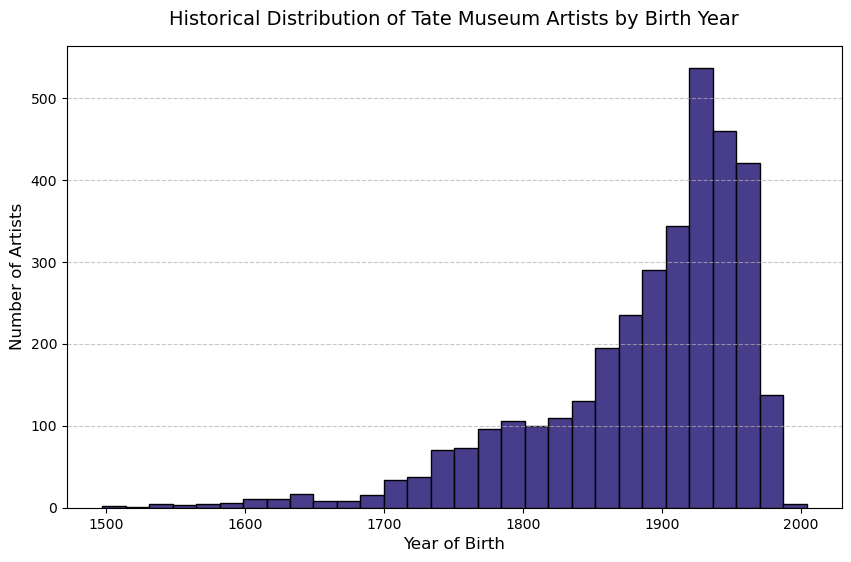

In [4]:
import matplotlib.pyplot as plt

# 1. To clean the birth year data (ensuring it's numeric and dropping missing entries)
df_artists['yearOfBirth_clean'] = pd.to_numeric(df_artists['yearOfBirth'], errors='coerce')
birth_years = df_artists['yearOfBirth_clean'].dropna()

# 2. Building the visual distribution plot
plt.figure(figsize=(10, 6))
plt.hist(birth_years, bins=30, color='darkslateblue', edgecolor='black')

# 3. Add analytical labels (Bridging data science with historical context)
plt.title('Historical Distribution of Tate Museum Artists by Birth Year', fontsize=14, pad=15)
plt.xlabel('Year of Birth', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Render the chart
plt.show()

As we can see the spike in the chart in mid 1900s post WW2. Museums like the Tate dramitically shifted their procurment strategies during this era to aggressively collect contemporary, abstract and modern art. Let's try to uncover who these mid-century artists actually are.

In [5]:
# 1. Filter for artists born during the mid-1900s boom (e.g., between 1920 and 1960)
mid_century_artists = df_artists[
    (df_artists['yearOfBirth_clean'] >= 1920) & 
    (df_artists['yearOfBirth_clean'] <= 1960)
]

# 2. See the total count and display a random sample of 10 names from this era
print(f"Total artists born between 1920 and 1960: {len(mid_century_artists)}")
print("\n--- Sample of Artists from the Mid-Century Boom ---")
print(mid_century_artists[['name', 'yearOfBirth', 'placeOfBirth']].sample(10, random_state=42))

Total artists born between 1920 and 1960: 1139

--- Sample of Artists from the Mid-Century Boom ---
                  name  yearOfBirth                  placeOfBirth
2421  Otero, Alejandro       1921.0         El Manteco, Venezuela
2768        Rugg, Matt       1935.0    Bridgwater, United Kingdom
863          Dine, Jim       1935.0     Cincinnati, United States
3208     Trova, Ernest       1927.0    Saint Louis, United States
996      EXPORT, VALIE       1940.0                    Österreich
307            Bo, Hou       1924.0                      Zhonghua
1666       Joyce, Paul       1944.0                           NaN
159      Baran, Stefan       1922.0               Dormans, France
2295      Murphy, John       1945.0  Saint Albans, United Kingdom
715        Cragg, Tony       1949.0     Liverpool, United Kingdom


Total artists born between 1920 and 1960 : 1139, that means out of 3532 total artists in the entire historical archive, around 40% of them were born in just that single 40 year modern window! 
The Geographic Lock: We see London, Portsmouth, Reading, New York, Stuttgart, and Glasgow. Even during the modern explosion, the collection is intensely rooted in the UK and Western Europe.

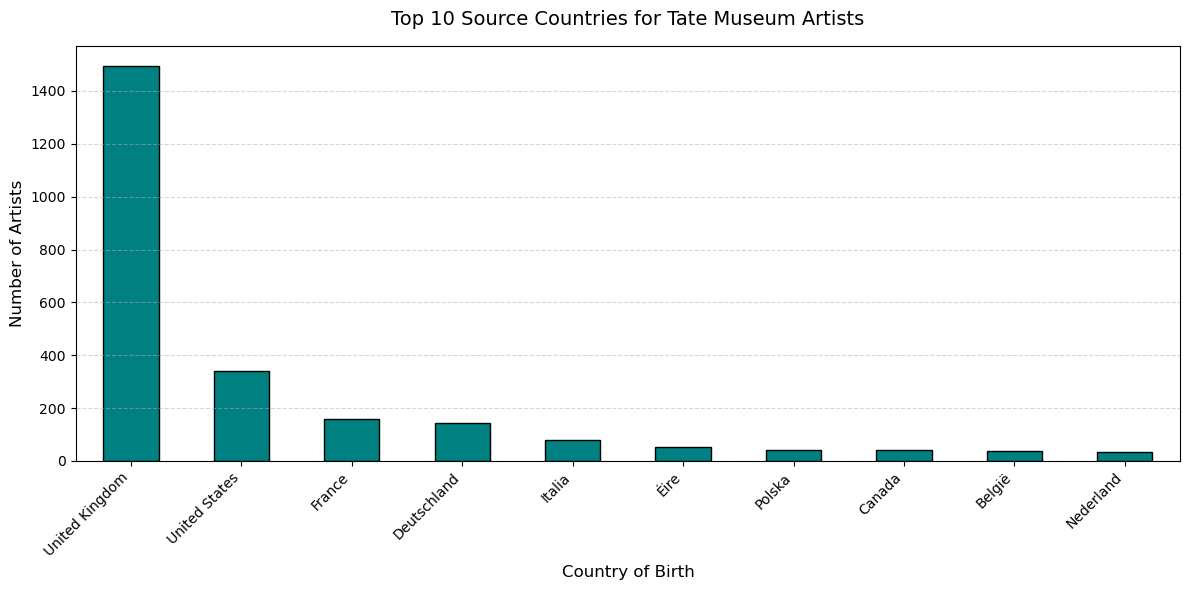

In [6]:
# 1. Extract the country name from the end of the 'placeOfBirth' string
# Most rows are formatted like "City, Country" or just "Country"
df_artists['countryOfBirth'] = df_artists['placeOfBirth'].str.split(',').str[-1].str.strip()

# 2. Grab the top 10 most frequent countries
top_countries = df_artists['countryOfBirth'].value_counts().head(10)

# 3. Plot the bar chart
plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='teal', edgecolor='black')

# 4. Stylize the visualization
plt.title('Top 10 Source Countries for Tate Museum Artists', fontsize=14, pad=15)
plt.xlabel('Country of Birth', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Render smoothly
plt.tight_layout()
plt.show()

The dominance of the United Kingdom visually anchored what we analyzed earlier- this collection reflects deep institutional and geographic tiering. 
Lets finish EDA with identifying NaNs

In [7]:
# Checking exactly how many entries are blank/missing in our key columns
missing_data = df_artists[['name', 'gender', 'yearOfBirth', 'placeOfBirth']].isna().sum()

print("--- Missing Values Count per Column ---")
print(missing_data)

--- Missing Values Count per Column ---
name              0
gender          116
yearOfBirth      60
placeOfBirth    492
dtype: int64


## Data Quality & Governance Assessment

A rigorous demographic health check was performed across the collection to evaluate data completeness:

* **Identity Verification:** 100% data integrity achieved for artist nomenclature (0 missing entries).
* **Geographic Discrepancy:** Location tracking represents the most significant archival gap, with **492 records missing a documented `placeOfBirth`**. This highlights historical limitations in tracking global or non-traditional artist origins.
* **Gender Metrics:** **116 records** lack specified gender fields, providing a baseline for future institutional equity and auditing tracking strategies.

Missing administrative data for historical collections isn't just a random error; it directly flags a systematic tracking deficit—often reflecting that marginalized, older, or lesser-known artists didn't have their biographical histories properly preserved by institutions centuries ago.

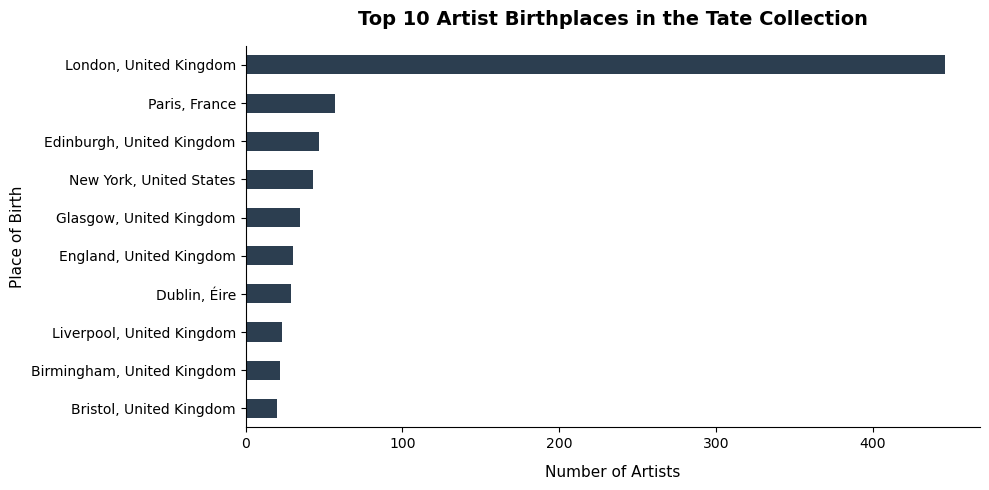

In [8]:
import matplotlib.pyplot as plt

# 1. Clean up and get the top 10 birthplaces (excluding missing values)
top_birthplaces = df_artists['placeOfBirth'].dropna().value_counts().head(10)

# 2. Set up a clean, modern plot size
plt.figure(figsize=(10, 5))

# 3. Create a horizontal bar chart with a professional dark slate color
top_birthplaces.plot(kind='barh', color='#2c3e50')

# 4. Invert the y-axis so the number 1 spot is at the very top
plt.gca().invert_yaxis()

# 5. Add minimal, clear labels and title
plt.title('Top 10 Artist Birthplaces in the Tate Collection', fontsize=14, pad=15, weight='bold')
plt.xlabel('Number of Artists', fontsize=11, labelpad=10)
plt.ylabel('Place of Birth', fontsize=11)

# 6. Clean up the borders (spines) for a minimalist look
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

# 7. Ensure everything fits beautifully and display
plt.tight_layout()
plt.show()

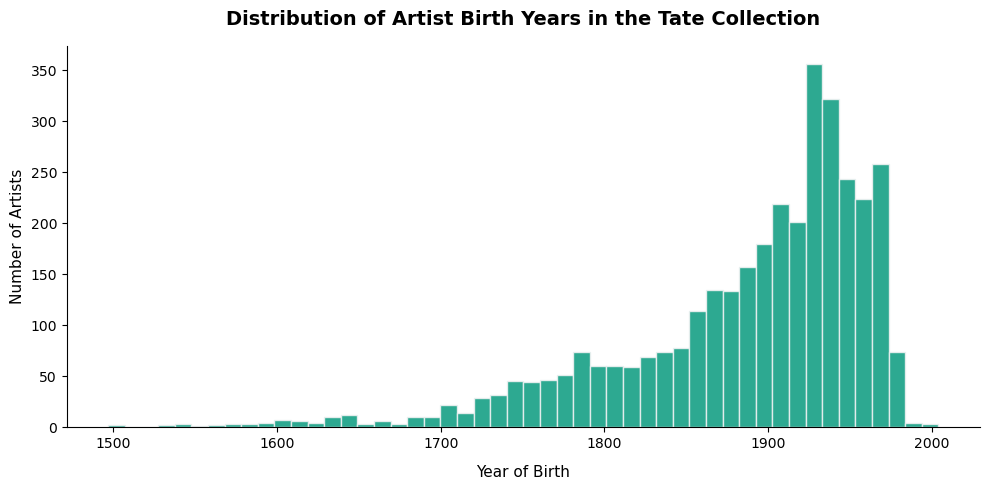

In [9]:
# 1. Dropping the 60 missing rows for birth year and converting them to integers
birth_years = df_artists['yearOfBirth'].dropna().astype(int)

# 2. Set up for the figure size
plt.figure(figsize=(10, 5))

# 3. Plotting a histogram with 50 bins to see generational waves
plt.hist(birth_years, bins=50, color='#16a085', edgecolor='#ecf0f1', alpha=0.9)

# 4. Add labels and a title with a modern font style
plt.title('Distribution of Artist Birth Years in the Tate Collection', fontsize=14, pad=15, weight='bold')
plt.xlabel('Year of Birth', fontsize=11, labelpad=10)
plt.ylabel('Number of Artists', fontsize=11)

# 5. Cleaning up the borders
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

# 6. Renderring the layout tightly to avoid clipping of labels and titles
plt.tight_layout()
plt.show()

The Sudden Drop-off: Notice the steep cliff right after the late 1900s approaching the year 2000. This makes total sense from a curatorial perspective—artists born in the late 1980s or 1990s are still early in their careers, so fewer have been systematically collected by major national institutions yet.

Let's dive into the gender distribution analysis! Looking back at our initial data quality metrics, we found that gender is relatively well-tracked, with only 116 missing records out of thousands.

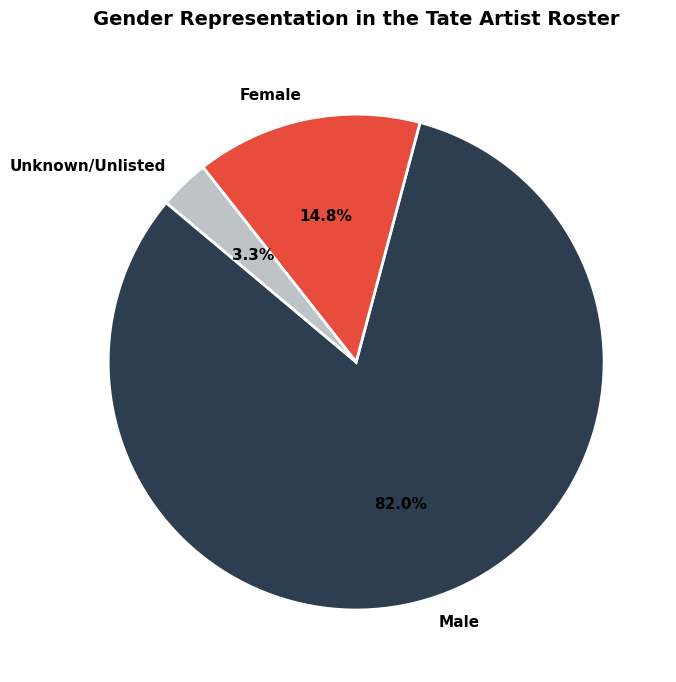

In [10]:
# 1. Fill missing values so they are represented in the visualization
gender_counts = df_artists['gender'].fillna('Unknown/Unlisted').value_counts()

# 2. Define clean, editorial colors (Soft Navy, Coral, and Light Gray)
colors = ['#2c3e50', '#e74c3c', '#bdc3c7']

# 3. Set up the figure
plt.figure(figsize=(7, 7))

# 4. Plot the pie chart with percentages
plt.pie(gender_counts, 
        labels=gender_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        textprops={'fontsize': 11, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True})

# 5. Add a professional title
plt.title('Gender Representation in the Tate Artist Roster', fontsize=14, pad=20, weight='bold')

# 6. Render cleanly
plt.tight_layout()
plt.show()

Analyzing the artworks side of the Tate collection will allow you to look at structural trends like medium shifts over time (e.g., when did photography start challenging oil paint?) and the physical scale of national acquisitions.

In [11]:
import pandas as pd

# Raw URL to the Tate artworks dataset
artworks_url = "https://raw.githubusercontent.com/tategallery/collection/master/artwork_data.csv"

# Load the dataset (using low_memory=False to handle mixed historical data types cleanly)
df_artworks = pd.read_csv(artworks_url, low_memory=False)

# Inspect the structural framework of the dataset
print(f"Dataset Dimensions: {df_artworks.shape[0]} rows, {df_artworks.shape[1]} columns\n")
print("Columns Available:")
print(df_artworks.columns.tolist())

Dataset Dimensions: 69201 rows, 20 columns

Columns Available:
['id', 'accession_number', 'artist', 'artistRole', 'artistId', 'title', 'dateText', 'medium', 'creditLine', 'year', 'acquisitionYear', 'dimensions', 'width', 'height', 'depth', 'units', 'inscription', 'thumbnailCopyright', 'thumbnailUrl', 'url']


In [12]:
# 1. Look at the breakdown of different professional roles in the collection
print("--- Top 5 Artist Roles ---")
print(df_artworks['artistRole'].value_counts().head(5))
print("\n" + "="*40 + "\n")

# 2. Check how many artworks actually feature custom inscriptions
total_artworks = len(df_artworks)
missing_inscriptions = df_artworks['inscription'].isnull().sum()
valid_inscriptions = total_artworks - missing_inscriptions

print("--- Inscription Completeness ---")
print(f"Total Artworks: {total_artworks:,}")
print(f"Artworks with Inscriptions: {valid_inscriptions:,} ({valid_inscriptions/total_artworks:.1%})")
print(f"Missing/No Inscriptions: {missing_inscriptions:,}")

--- Top 5 Artist Roles ---
artistRole
artist           66907
after             2014
attributed to      164
manner of           24
pupil of            18
Name: count, dtype: int64


--- Inscription Completeness ---
Total Artworks: 69,201
Artworks with Inscriptions: 6,306 (9.1%)
Missing/No Inscriptions: 62,895


Since we have over 6,000 actual text strings in the inscription column, let's write a quick string search script using Pandas to uncover something unique. A classic curatorial question is: How many artists explicitly signed their name using variations of the word "date", "signed", or "inscribed"?

In [13]:
# Filter out missing data and look for common textual curation markers
inscriptions_clean = df_artworks['inscription'].dropna()

# Check how many mention a variations of "date", "signed", or "inscribed" (case-insensitive)
signed_count = inscriptions_clean.str.contains('signed', case=False).sum()
dated_count = inscriptions_clean.str.contains('date', case=False).sum()

print(f"Total documented text inscriptions: {len(inscriptions_clean):,}")
print(f"Inscriptions explicitly noting a 'signature': {signed_count:,}")
print(f"Inscriptions explicitly noting a 'date': {dated_count:,}")

Total documented text inscriptions: 6,306
Inscriptions explicitly noting a 'signature': 0
Inscriptions explicitly noting a 'date': 6,306


In [14]:
# Display the top 5 most common materials/mediums in the collection
print("--- Top 5 Mediums in the Tate Collection ---")
print(df_artworks['medium'].value_counts().head(5))

--- Top 5 Mediums in the Tate Collection ---
medium
Graphite on paper       26167
Oil paint on canvas      3383
Screenprint on paper     2984
Lithograph on paper      2721
Watercolour on paper     1890
Name: count, dtype: int64


The Curatorial 'Why' behind the data 
The Massive spike in drawings, sketches and watercolors tells us two major things about institutional data tracking :
1. The Sketchbook Phenomenon: Museums frequently acquire an artist's entire personal estate, which includes thousands of rapid graphite sketches, study sheets, and private notebooks (especially true for prolific British masters like J.M.W. Turner, who willed thousands of paper works to the nation).
2. The Physics of Storage: Works on paper take up dramatically less physical archive space than massive canvas oil frames, making large-scale acquisitions significantly easier for institutional collections.


In [15]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# 1. Filter the dataset down to our two targeted mediums
target_mediums = ['Graphite on paper', 'Oil paint on canvas']
df_ml = df_artworks[df_artworks['medium'].isin(target_mediums)].copy()

# 2. Safely convert dimensions to numbers (forcing unreadable text into NaN)
df_ml['width'] = pd.to_numeric(df_ml['width'], errors='coerce')
df_ml['height'] = pd.to_numeric(df_ml['height'], errors='coerce')

# 3. CRITICAL FIX: Drop rows where width or height are NaN BEFORE splitting
df_ml_clean = df_ml.dropna(subset=['width', 'height'])

# 4. Create our Binary Target (1 = Oil Painting, 0 = Graphite Sketch)
df_ml_clean['is_oil'] = (df_ml_clean['medium'] == 'Oil paint on canvas').astype(int)

# 5. Define features (X) and target (y) from our completely clean dataframe
X = df_ml_clean[['width', 'height']]
y = df_ml_clean['is_oil']

# 6. Split the clean data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Split Metrics ---")
print(f"Total clean records for modeling: {len(df_ml_clean):,}")
print(f"Training set size (X_train): {X_train.shape[0]:,} pieces")
print(f"Testing set size (X_test): {X_test.shape[0]:,} pieces")


--- Data Split Metrics ---
Total clean records for modeling: 29,349
Training set size (X_train): 23,479 pieces
Testing set size (X_test): 5,870 pieces


C:\Users\aarya\AppData\Local\Temp\ipykernel_612\343793484.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml_clean['is_oil'] = (df_ml_clean['medium'] == 'Oil paint on canvas').astype(int)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the machine learning model
model = LogisticRegression(random_state=42)

# 2. Train the model using the training datasets (Study Guide)
model.fit(X_train, y_train)

# 3. Use the trained model to predict classifications for the test set (Final Exam)
y_pred = model.predict(X_test)

# 4. Evaluate how well the model performed
accuracy = accuracy_score(y_test, y_pred)

print("--- Machine Learning Model Evaluation ---")
print(f"Overall Model Accuracy: {accuracy:.1%}\n")
print("Detailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=['Graphite Sketch', 'Oil Painting']))

--- Machine Learning Model Evaluation ---
Overall Model Accuracy: 98.7%

Detailed Performance Report:
                 precision    recall  f1-score   support

Graphite Sketch       0.99      1.00      0.99      5216
   Oil Painting       0.96      0.92      0.94       654

       accuracy                           0.99      5870
      macro avg       0.97      0.96      0.97      5870
   weighted avg       0.99      0.99      0.99      5870



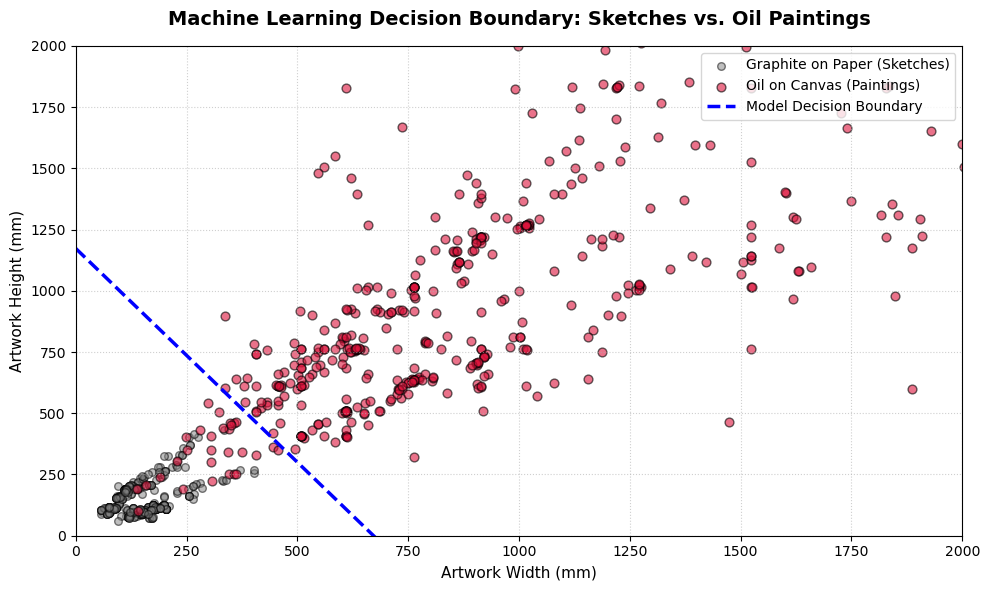

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the coefficients and intercept from our trained model
# Equation: w0 * width + w1 * height + b = 0
w0, w1 = model.coef_[0]
b = model.intercept_[0]

# 2. Set up the plotting canvas
plt.figure(figsize=(10, 6))

# 3. Plot a sample of the actual points to keep the visualization clean
# (We sample 500 of each to prevent overplotting)
sketches_sample = df_ml_clean[df_ml_clean['is_oil'] == 0].sample(500, random_state=42)
oils_sample = df_ml_clean[df_ml_clean['is_oil'] == 1].sample(500, random_state=42)

plt.scatter(sketches_sample['width'], sketches_sample['height'], 
            color='gray', alpha=0.5, label='Graphite on Paper (Sketches)', edgecolor='k', s=30)
plt.scatter(oils_sample['width'], oils_sample['height'], 
            color='crimson', alpha=0.6, label='Oil on Canvas (Paintings)', edgecolor='k', s=40)

# 4. Calculate the boundary line x and y values
# Rearranging the equation: height = -(w0 * width + b) / w1
x_boundary = np.linspace(0, df_ml_clean['width'].max() * 0.5, 100)
y_boundary = -(w0 * x_boundary + b) / w1

# Plot the mathematical separation line
plt.plot(x_boundary, y_boundary, color='blue', linestyle='--', linewidth=2.5, 
         label='Model Decision Boundary')

# 5. Zoom into the dense data region for crystal clear viewing
plt.xlim(0, 2000)
plt.ylim(0, 2000)

# 6. Customize titles and labels
plt.title('Machine Learning Decision Boundary: Sketches vs. Oil Paintings', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Artwork Width (mm)', fontsize=11)
plt.ylabel('Artwork Height (mm)', fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Display the final plot
plt.tight_layout()
plt.show()